# Day 25 — Detailed Error / Failure Analysis

## Objective

The objective of Day 25 is to inspect predictions from the final frozen models,identify recurring detection errors,analyse difficult classes and visual conditions,and document the main limitations and likely failure conditions of the underwater object-detection system.

The analysis is performed on the final frozen configurations without retraining or changing the selected model settings.

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.6 MB/s eta 0:00:00


In [ ]:
import os
import glob
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
FINAL_DIR="/content/drive/MyDrive/Day22_Final_Model"
print("Final folder exists:",os.path.exists(FINAL_DIR))
print("\nFolder contents:")
print(os.listdir(FINAL_DIR))

Final folder exists: True

Folder contents:
['H03_Training', 'H04_Training', 'final_frozen_configuration.csv', 'DIAT_Baseline', 'Day22_Final_Freeze_Summary.md']


In [ ]:
model_paths={
    "DIAT":"/content/drive/MyDrive/Day22_Final_Model/DIAT_Baseline/weights/best.pt",
    "Aquatic Plant":"/content/drive/MyDrive/Day22_Final_Model/H03_Training/Aquatic_Plant_H03/weights/best.pt",
    "Well":"/content/drive/MyDrive/Day22_Final_Model/H04_Training/Well_H04/weights/best.pt"
}

for name,path in model_paths.items():
    print(name,":",os.path.exists(path))
    print(path)
    print()

DIAT : True
/content/drive/MyDrive/Day22_Final_Model/DIAT_Baseline/weights/best.pt

Aquatic Plant : True
/content/drive/MyDrive/Day22_Final_Model/H03_Training/Aquatic_Plant_H03/weights/best.pt

Well : True
/content/drive/MyDrive/Day22_Final_Model/H04_Training/Well_H04/weights/best.pt



In [ ]:
import os
paths={
    "DIAT":"/content/Dataset_V1/DIATAquarium.v4i.yolov8/valid/images",
    "Aquatic Plant":"/content/Dataset_V1_Enhanced/Aquatic Plant.v2i.yolov8/test/images",
    "Well":"/content/Dataset_V1_Enhanced/well.v8i.yolov8/test/images"
}
for name,path in paths.items():
    print("\n",name)
    print("Path:",path)
    print("Exists:",os.path.exists(path))

    if os.path.exists(path):
        files=os.listdir(path)
        print("Number of files:",len(files))
        print("First 5 files:",files[:5])


 DIAT
Path: /content/Dataset_V1/DIATAquarium.v4i.yolov8/valid/images
Exists: False

 Aquatic Plant
Path: /content/Dataset_V1_Enhanced/Aquatic Plant.v2i.yolov8/test/images
Exists: False

 Well
Path: /content/Dataset_V1_Enhanced/well.v8i.yolov8/test/images
Exists: False


In [ ]:
import os
import shutil
sources={
    "DIAT":"/content/drive/MyDrive/Dataset_V1/DIATAquarium.v4i.yolov8/valid",
    "Aquatic Plant":"/content/drive/MyDrive/Dataset_V1_Enhanced/Aquatic Plant.v2i.yolov8/test",
    "Well":"/content/drive/MyDrive/Dataset_V1_Enhanced/well.v8i.yolov8/test"
}
destinations={
    "DIAT":"/content/Day25_Data/DIAT",
    "Aquatic Plant":"/content/Day25_Data/Aquatic_Plant",
    "Well":"/content/Day25_Data/Well"
}
for name in sources:
    if os.path.exists(destinations[name]):
        shutil.rmtree(destinations[name])
    shutil.copytree(sources[name],destinations[name])
    print(name,"copied successfully")
print("\nDay 25 evaluation data restored.")

DIAT copied successfully
Aquatic Plant copied successfully
Well copied successfully

Day 25 evaluation data restored.


In [ ]:
for name,path in destinations.items():
    image_dir=os.path.join(path,"images")
    label_dir=os.path.join(path,"labels")
    images=[f for f in os.listdir(image_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
    labels=[f for f in os.listdir(label_dir) if f.endswith(".txt")]
    print(name)
    print("Images:",len(images))
    print("Labels:",len(labels))
    print()

DIAT
Images: 773
Labels: 773

Aquatic Plant
Images: 89
Labels: 89

Well
Images: 184
Labels: 184



In [ ]:
from ultralytics import YOLO
DIAT_MODEL="/content/drive/MyDrive/Day22_Final_Model/DIAT_Baseline/weights/best.pt"
AP_MODEL="/content/drive/MyDrive/Day22_Final_Model/H03_Training/Aquatic_Plant_H03/weights/best.pt"
WELL_MODEL="/content/drive/MyDrive/Day22_Final_Model/H04_Training/Well_H04/weights/best.pt"
diat_model=YOLO(DIAT_MODEL)
ap_model=YOLO(AP_MODEL)
well_model=YOLO(WELL_MODEL)
print("DIAT model loaded")
print("Aquatic Plant H03 model loaded")
print("Well H04 model loaded")

DIAT model loaded
Aquatic Plant H03 model loaded
Well H04 model loaded


In [ ]:
import os
OUTPUT_DIR="/content/Day25_Predictions"
for folder in ["DIAT","Aquatic_Plant","Well"]:
    os.makedirs(os.path.join(OUTPUT_DIR,folder),exist_ok=True)
print("Prediction folders created.")

Prediction folders created.


In [ ]:
DIAT_IMAGES="/content/Day25_Data/DIAT/images"
AP_IMAGES="/content/Day25_Data/Aquatic_Plant/images"
WELL_IMAGES="/content/Day25_Data/Well/images"
print("DIAT images:",len(os.listdir(DIAT_IMAGES)))
print("Aquatic Plant images:",len(os.listdir(AP_IMAGES)))
print("Well images:",len(os.listdir(WELL_IMAGES)))

DIAT images: 773
Aquatic Plant images: 89
Well images: 184


In [ ]:
diat_results=diat_model.predict(
    source=DIAT_IMAGES,
    conf=0.25,
    imgsz=640,
    device=0,
    save=True,
    project=OUTPUT_DIR,
    name="DIAT",
    exist_ok=True
)
print("DIAT prediction completed.")


image 1/773 /content/Day25_Data/DIAT/images/av0_0_20231228_094444_mp4-103_jpg.rf.127ceea2cf662e7fde8c90468061c986.jpg: 480x640 1 Aquatic Plant, 1 Fish, 8.1ms
image 2/773 /content/Day25_Data/DIAT/images/av0_0_20231228_094444_mp4-106_jpg.rf.12f8943444344b67f425b1574a2cd69a.jpg: 480x640 1 Aquatic Plant, 5 Fishs, 1 Fishes, 8.0ms
image 3/773 /content/Day25_Data/DIAT/images/av0_0_20231228_094444_mp4-110_jpg.rf.264e4180bc12ff178db40a8bb6b458e6.jpg: 480x640 1 Aquatic Plant, 6 Fishs, 3 Fishess, 7.9ms
image 4/773 /content/Day25_Data/DIAT/images/av0_0_20231228_094444_mp4-116_jpg.rf.564fa82ff8bfc7395035693dfbe3225f.jpg: 480x640 1 Aquatic Plant, 9 Fishs, 1 Fishes, 9.5ms
image 5/773 /content/Day25_Data/DIAT/images/av0_0_20231228_094444_mp4-121_jpg.rf.f7a2532e271d10c61d4a7cca144f5707.jpg: 480x640 1 Aquatic Plant, 7.3ms
image 6/773 /content/Day25_Data/DIAT/images/av0_0_20231228_094444_mp4-122_jpg.rf.641eae1271fd5c0b82f73923d80a0207.jpg: 480x640 1 Aquatic Plant, 7.2ms
image 7/773 /content/Day25_Data/D

In [ ]:
import os
DIAT_OUTPUT="/content/Day25_Predictions/DIAT"
print("DIAT output exists:",os.path.exists(DIAT_OUTPUT))
if os.path.exists(DIAT_OUTPUT):
    files=os.listdir(DIAT_OUTPUT)
    print("Number of output files:",len(files))
    print("First 10 files:",files[:10])

DIAT output exists: True
Number of output files: 773
First 10 files: ['av0_0_20240222_103703_005129_jpg.rf.3e0e540afe2bc9cff79282dc670099e4.jpg', 'av0_0_20240222_102152_001105_jpg.rf.992d81308cc784d4dd46a8d0d560d0d7.jpg', 'av0_0_20240222_105838_000562_jpg.rf.8091401f8d45ee2b60bc266e1330f800.jpg', 'av0_0_20240222_102152_004048_jpg.rf.5ede3769edd706176946a590c8e21384.jpg', 'av0_0_20231228_102111_mp4-570_jpg.rf.4545e89ae88a1b2a223aacbcd1ad6a43.jpg', 'av0_0_20240222_105838_002105_jpg.rf.9ce9263812b8869ee85345c34dbd66c2.jpg', 'av0_0_20240222_102152_004842_jpg.rf.8ae76d07380abbcab707c5aad7106389.jpg', 'av0_0_20240222_102152_003816_jpg.rf.e7e1a3b748c2dc97e4d179895c2b0977.jpg', 'av0_0_20240222_103703_004772_jpg.rf.876d82f27da54161f2b778b364ccb9dd.jpg', 'av0_0_20240222_105838_001568_jpg.rf.6886525288964a9dab80077229d6388b.jpg']


In [ ]:
import os
import numpy as np
from PIL import Image
from ultralytics import YOLO
DIAT_IMAGES="/content/Day25_Data/DIAT/images"
DIAT_OUTPUT="/content/Day25_Predictions/DIAT"
image_files=[
    os.path.join(DIAT_IMAGES,f)
    for f in os.listdir(DIAT_IMAGES)
    if f.lower().endswith((".jpg",".jpeg",".png"))
]
print("DIAT evaluation images:",len(image_files))

DIAT evaluation images: 773


In [ ]:
diat_analysis=[]
for image_path in image_files:
    result=diat_model.predict(
        source=image_path,
        conf=0.001,
        imgsz=640,
        device=0,
        verbose=False
    )[0]
    if result.boxes is not None and len(result.boxes)>0:
        confidences=result.boxes.conf.cpu().numpy()
        classes=result.boxes.cls.cpu().numpy().astype(int)
        diat_analysis.append({
            "image":os.path.basename(image_path),
            "detections":len(confidences),
            "max_confidence":float(np.max(confidences)),
            "mean_confidence":float(np.mean(confidences)),
            "min_confidence":float(np.min(confidences))
        })
    else:
        diat_analysis.append({
            "image":os.path.basename(image_path),
            "detections":0,
            "max_confidence":0.0,
            "mean_confidence":0.0,
            "min_confidence":0.0
        })
diat_df=pd.DataFrame(diat_analysis)
print("Analysis completed.")
print(diat_df.head())

Analysis completed.
                                               image  detections  \
0  av0_0_20240222_103703_005129_jpg.rf.3e0e540afe...           1   
1  av0_0_20240222_102152_001105_jpg.rf.992d81308c...           2   
2  av0_0_20240222_105838_000562_jpg.rf.8091401f8d...           2   
3  av0_0_20240222_102152_004048_jpg.rf.5ede3769ed...          25   
4  av0_0_20231228_102111_mp4-570_jpg.rf.4545e89ae...           3   

   max_confidence  mean_confidence  min_confidence  
0        0.888130         0.888130        0.888130  
1        0.923676         0.902941        0.882206  
2        0.854396         0.841051        0.827706  
3        0.823033         0.134885        0.001030  
4        0.006423         0.003049        0.001035  


In [ ]:
weak_diat=diat_df.sort_values(
    ["detections","max_confidence"],
    ascending=[True,True]
).head(20)
weak_diat

,image,detections,max_confidence,mean_confidence,min_confidence
43,av0_0_20231228_102111_mp4-628_jpg.rf.7fbd82297...,0,0.000000,0.000000,0.000000
145,av0_0_20231228_103918_mp4-147_jpg.rf.b8474a9a4...,0,0.000000,0.000000,0.000000
297,av0_0_20231228_102111_mp4-610_jpg.rf.a59a8a455...,0,0.000000,0.000000,0.000000
414,av0_0_20231228_103918_mp4-207_jpg.rf.55d33ae99...,0,0.000000,0.000000,0.000000
453,av0_0_20231228_103918_mp4-186_jpg.rf.1d75f63d8...,0,0.000000,0.000000,0.000000
482,av0_0_20231228_102111_mp4-532_jpg.rf.9fe4c9fd0...,0,0.000000,0.000000,0.000000
551,av0_0_20231228_103918_mp4-217_jpg.rf.e7b2d78d9...,0,0.000000,0.000000,0.000000
607,av0_0_20231228_103918_mp4-221_jpg.rf.6499ef231...,0,0.000000,0.000000,0.000000
730,av0_0_20231228_102111_mp4-542_jpg.rf.033735316...,0,0.000000,0.000000,0.000000
756,av0_0_20231228_103918_mp4-199_jpg.rf.47172bc4a...,0,0.000000,0.000000,0.000000


Image: av0_0_20231228_102111_mp4-628_jpg.rf.7fbd822970d0310921003e9de368bcdf.jpg
Ground-truth objects: 0
Ground-truth labels: []


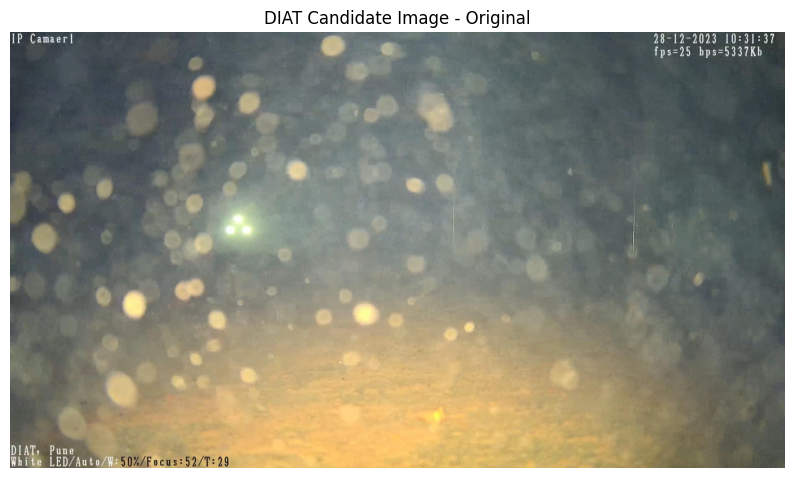

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
# Get the first suspicious DIAT image
image_name=weak_diat.iloc[0]["image"]
image_path=os.path.join(DIAT_IMAGES,image_name)
label_path=os.path.join("/content/Day25_Data/DIAT/labels",os.path.splitext(image_name)[0]+".txt")
# Read image
img=cv2.imread(image_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
# Read ground-truth labels
gt_labels=[]
if os.path.exists(label_path):
    with open(label_path,"r") as f:
        for line in f:
            parts=line.strip().split()
            if len(parts)==5:
                gt_labels.append([float(x) for x in parts])

print("Image:",image_name)
print("Ground-truth objects:",len(gt_labels))
print("Ground-truth labels:",gt_labels)
# Show original image
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("DIAT Candidate Image - Original")
plt.show()

In [ ]:
print("Image:",image_name)
print("Label file:",label_path)
if os.path.exists(label_path):
    with open(label_path,"r") as f:
        label_lines=[line.strip() for line in f if line.strip()]
    print("Number of ground-truth objects:",len(label_lines))
    print("Ground-truth labels:")
    for line in label_lines:
        print(line)
else:
    print("Label file not found")

Image: av0_0_20231228_102111_mp4-628_jpg.rf.7fbd822970d0310921003e9de368bcdf.jpg
Label file: /content/Day25_Data/DIAT/labels/av0_0_20231228_102111_mp4-628_jpg.rf.7fbd822970d0310921003e9de368bcdf.txt
Number of ground-truth objects: 0
Ground-truth labels:


In [ ]:
import os
import numpy as np
import pandas as pd
DIAT_LABELS="/content/Day25_Data/DIAT/labels"
failure_candidates=[]
for _,row in diat_df.iterrows():
    image_name=row["image"]
    label_path=os.path.join(
        DIAT_LABELS,
        os.path.splitext(image_name)[0]+".txt"
    )
    if not os.path.exists(label_path):
        continue

    with open(label_path,"r") as f:
        gt_lines=[line.strip() for line in f if line.strip()]

    gt_count=len(gt_lines)
    if gt_count>0:
        failure_candidates.append({
            "image":image_name,
            "ground_truth_objects":gt_count,
            "detections":int(row["detections"]),
            "max_confidence":row["max_confidence"],
            "mean_confidence":row["mean_confidence"]
        })

failure_df=pd.DataFrame(failure_candidates)

print("DIAT images containing ground-truth objects:",len(failure_df))

print("\nImages with objects but zero detections:")
print(
    failure_df[failure_df["detections"]==0]
    .sort_values("ground_truth_objects",ascending=False)
    .head(20)
)

DIAT images containing ground-truth objects: 714

Images with objects but zero detections:
                                                 image  ground_truth_objects  \
673  av0_0_20231228_102111_mp4-542_jpg.rf.033735316...                     1   

     detections  max_confidence  mean_confidence  
673           0             0.0              0.0  


Image: av0_0_20231228_102111_mp4-542_jpg.rf.0337353169612060465d4c9a971908d3.jpg
Label: /content/Day25_Data/DIAT/labels/av0_0_20231228_102111_mp4-542_jpg.rf.0337353169612060465d4c9a971908d3.txt

Ground-truth label:
1 0.36809375 0.12425925925925925 0.19340104166666663 0.2485185185185185


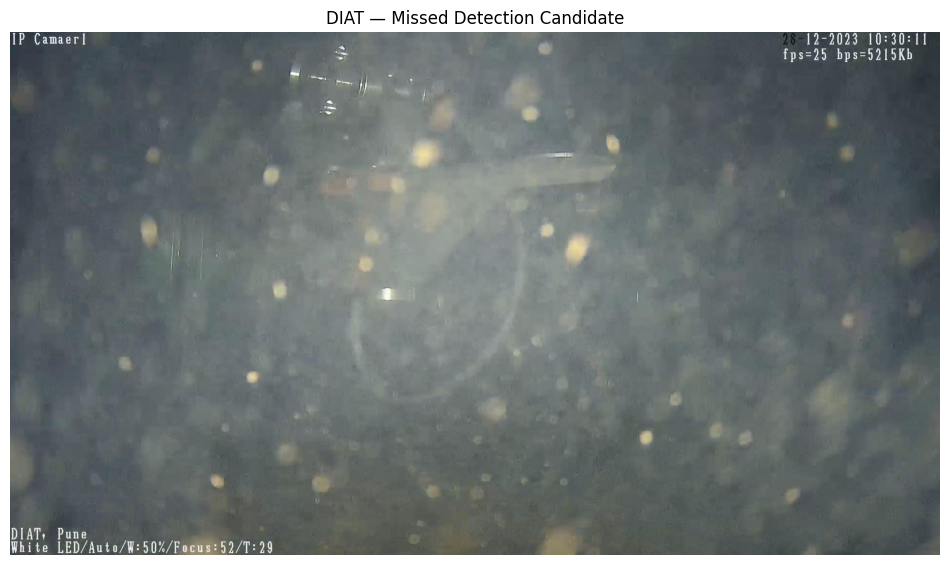

In [ ]:
failure_image=failure_df[
    failure_df["detections"]==0
].iloc[0]["image"]
failure_image_path=os.path.join(DIAT_IMAGES,failure_image)
failure_label_path=os.path.join(
    DIAT_LABELS,
    os.path.splitext(failure_image)[0]+".txt"
)
print("Image:",failure_image)
print("Label:",failure_label_path)
with open(failure_label_path,"r") as f:
    gt_lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in gt_lines:
    print(line)
img=cv2.imread(failure_image_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("DIAT — Missed Detection Candidate")
plt.show()

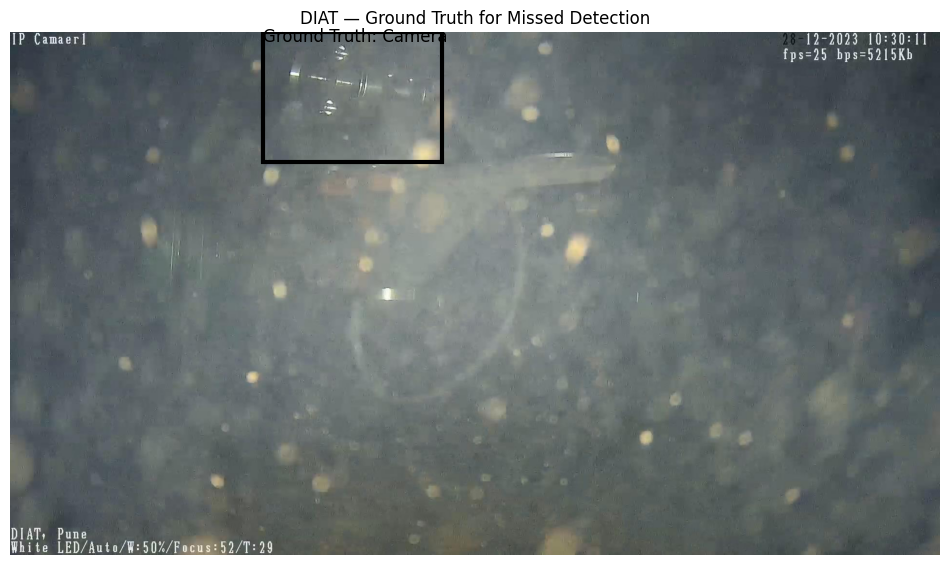

Class ID: 1
Class: Camera
Bounding box pixels: 521 0 892 268


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
# Read the label again
with open(failure_label_path,"r") as f:
    line=f.readline().strip()
parts=line.split()
class_id=float(parts[0])
x_center=float(parts[1])
y_center=float(parts[2])
box_width=float(parts[3])
box_height=float(parts[4])
# Read image
img=cv2.imread(failure_image_path)
h,w=img.shape[:2]
# Convert normalized YOLO coordinates to pixels
x_center=x_center*w
y_center=y_center*h
box_width=box_width*w
box_height=box_height*h
x1=int(x_center-box_width/2)
y1=int(y_center-box_height/2)
x2=int(x_center+box_width/2)
y2=int(y_center+box_height/2)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,7))
plt.imshow(img_rgb)
plt.gca().add_patch(
    plt.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        fill=False,
        linewidth=3
    )
)
plt.text(
    x1,
    max(y1+20,20),
    "Ground Truth: Camera",
    fontsize=12
)
plt.axis("off")
plt.title("DIAT — Ground Truth for Missed Detection")
plt.show()
print("Class ID:",int(class_id))
print("Class: Camera")
print("Bounding box pixels:",x1,y1,x2,y2)

In [ ]:
# Find DIAT images where YOLO made at least one prediction
# and inspect class/confidence information
DIAT_LABELS="/content/Day25_Data/DIAT/labels"
class_names=[
    "Aquatic Plant",
    "Camera",
    "Conch-Shell",
    "Fish",
    "Fishes",
    "Pluco",
    "Shark",
    "Temperature Sensor",
    "Water-Pump",
    "Water-filter",
    "betta"
]
print("DIAT classes:")
for i,name in enumerate(class_names):
    print(i,":",name)

DIAT classes:
0 : Aquatic Plant
1 : Camera
2 : Conch-Shell
3 : Fish
4 : Fishes
5 : Pluco
6 : Shark
7 : Temperature Sensor
8 : Water-Pump
9 : Water-filter
10 : betta


In [ ]:
import os
import pandas as pd
import numpy as np
class_names=[
    "Aquatic Plant",
    "Camera",
    "Conch-Shell",
    "Fish",
    "Fishes",
    "Pluco",
    "Shark",
    "Temperature Sensor",
    "Water-Pump",
    "Water-filter",
    "betta"
]
fish_confusion_candidates=[]
for image_path in image_files:
    result=diat_model.predict(
        source=image_path,
        conf=0.25,
        imgsz=640,
        device=0,
        verbose=False
    )[0]
    if result.boxes is None or len(result.boxes)==0:
        continue
    for box in result.boxes:
        cls=int(box.cls.item())
        conf=float(box.conf.item())

        if cls in [3,4]:
            fish_confusion_candidates.append({
                "image":os.path.basename(image_path),
                "predicted_class":class_names[cls],
                "confidence":conf
            })
fish_confusion_df=pd.DataFrame(fish_confusion_candidates)
print("Fish/Fishes prediction candidates:",len(fish_confusion_df))
print(fish_confusion_df.sort_values("confidence").head(20))

Fish/Fishes prediction candidates: 351
                                                 image predicted_class  \
294  av0_0_20231228_094444_mp4-242_jpg.rf.dc48ac106...            Fish   
264  av0_0_20231228_094444_mp4-512_jpg.rf.02338e1e1...            Fish   
219  av0_0_20240222_105838_004254_jpg.rf.20276a9250...            Fish   
23   av0_0_20231228_094444_mp4-739_jpg.rf.e08e1b2cd...            Fish   
178  av0_0_20231228_094444_mp4-89_jpg.rf.15efd5fd81...          Fishes   
27   av0_0_20231228_094444_mp4-316_jpg.rf.1f642b82a...            Fish   
267  av0_0_20231228_102111_mp4-86_jpg.rf.cb6192fc87...            Fish   
175  av0_0_20231228_094444_mp4-16_jpg.rf.a0d7084f3e...            Fish   
287  av0_0_20231228_094444_mp4-46_jpg.rf.c9aada1c5a...            Fish   
33   av0_0_20231228_094444_mp4-17_jpg.rf.a4bc99190d...            Fish   
76   av0_0_20231228_103918_mp4-106_jpg.rf.a40ca4d14...            Fish   
110  av0_0_20231228_094444_mp4-116_jpg.rf.564fa82ff...            Fish   

In [ ]:
# Select the first Fish/Fishes candidate
candidate_image=fish_confusion_df.sort_values("confidence").iloc[0]["image"]
candidate_image_path=os.path.join(DIAT_IMAGES,candidate_image)
candidate_label_path=os.path.join(
    DIAT_LABELS,
    os.path.splitext(candidate_image)[0]+".txt"
)
print("Image:",candidate_image)
print("Label:",candidate_label_path)
# Read ground-truth labels
with open(candidate_label_path,"r") as f:
    candidate_gt=[line.strip() for line in f if line.strip()]
print("\nGround-truth labels:")
for line in candidate_gt:
    parts=line.split()
    class_id=int(float(parts[0]))
    print(
        "Class ID:",class_id,
        "Class:",class_names[class_id],
        "YOLO box:",parts[1:]
    )

Image: av0_0_20231228_094444_mp4-242_jpg.rf.dc48ac106f445ceb727c82fd6ab74713.jpg
Label: /content/Day25_Data/DIAT/labels/av0_0_20231228_094444_mp4-242_jpg.rf.dc48ac106f445ceb727c82fd6ab74713.txt

Ground-truth labels:
Class ID: 0 Class: Aquatic Plant YOLO box: ['0.40673828125', '0.810546875', '0.4462890625', '0.3645833333333333']
Class ID: 8 Class: Water-Pump YOLO box: ['0.107421875', '0.9134114583333334', '0.21484375', '0.14908854166666666']
Class ID: 4 Class: Fishes YOLO box: ['0.05126953125', '0.047526041666666664', '0.1025390625', '0.09505208333333333']


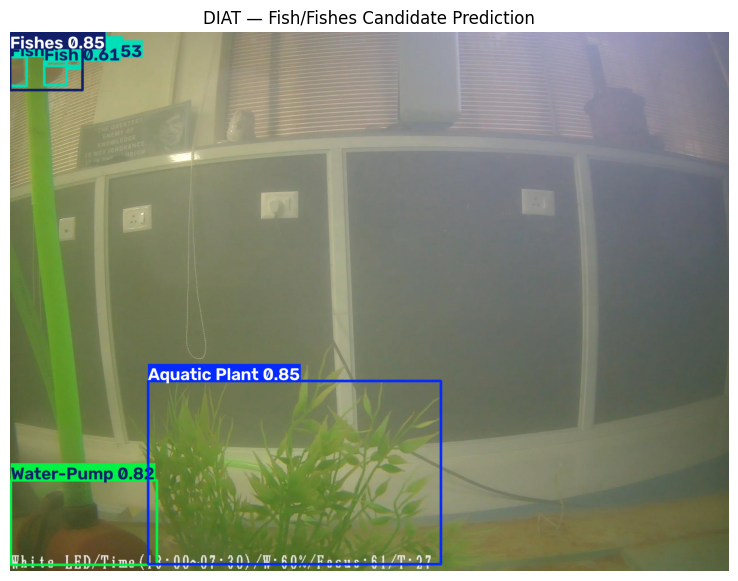

Predictions:
Predicted: Fishes | Confidence: 0.851
Predicted: Aquatic Plant | Confidence: 0.848
Predicted: Water-Pump | Confidence: 0.822
Predicted: Fish | Confidence: 0.605
Predicted: Fish | Confidence: 0.529
Predicted: Fish | Confidence: 0.479
Predicted: Fish | Confidence: 0.342
Predicted: Fish | Confidence: 0.29
Predicted: Fish | Confidence: 0.25


In [ ]:
result=diat_model.predict(
    source=candidate_image_path,
    conf=0.25,
    imgsz=640,
    device=0,
    verbose=False
)[0]
annotated=result.plot()
annotated_rgb=cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("DIAT — Fish/Fishes Candidate Prediction")
plt.show()
print("Predictions:")
for box in result.boxes:
    cls=int(box.cls.item())
    conf=float(box.conf.item())
    print(
        "Predicted:",
        class_names[cls],
        "| Confidence:",
        round(conf,3)
    )

## DIAT Aquarium — Error Analysis Summary

- Evaluation images: 773
- Final model: Original YOLOv8n
- Ground-truth labels: 773

### Confirmed Errors

1. **Missed Detection**
   - Ground truth: Camera
   - Prediction: No detection
   - Scene had high turbidity and low visibility.

2. **False Positive / Over-Detection**
   - Ground truth: Aquatic Plant,Water-Pump,Fishes
   - Model correctly detected these objects.
   - Model also produced several extra Fish predictions.

### Observations

- Some objects were missed in difficult underwater scenes.
- Extra Fish predictions were observed.
- Fish/Fishes confusion needs further inspection.

### Limitation

- DIAT has no separate local test set,so this analysis uses the available validation set.

### Conclusion

The DIAT model showed both missed detections and false-positive predictions. Difficult underwater conditions and additional Fish predictions are important areas for further analysis.

In [ ]:
AP_OUTPUT="/content/Day25_Predictions/Aquatic_Plant"
os.makedirs(AP_OUTPUT,exist_ok=True)
ap_results=ap_model.predict(
    source=AP_IMAGES,
    conf=0.25,
    imgsz=640,
    device=0,
    save=True,
    project="/content/Day25_Predictions",
    name="Aquatic_Plant",
    exist_ok=True
)
print("Aquatic Plant prediction completed.")


image 1/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_18_14_mp4-101_jpg.rf.6abd323038dd160acbc3851d27b5dcde.jpg: 640x640 1 Aquatic_plant, 7.2ms
image 2/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_18_14_mp4-117_jpg.rf.eb9b731bc7d4bdbe94167ca4e6f65600.jpg: 640x640 1 Aquatic_plant, 7.2ms
image 3/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_18_14_mp4-133_jpg.rf.d9c826e4b597d9d81a7d68d7084183c1.jpg: 640x640 1 Aquatic_plant, 7.2ms
image 4/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_18_14_mp4-155_jpg.rf.3f21dee61271dc8951fb2db16491e7c5.jpg: 640x640 1 Aquatic_plant, 7.2ms
image 5/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_18_14_mp4-174_jpg.rf.4beab975ec70c7f303607c8d4012e57e.jpg: 640x640 1 Aquatic_plant, 7.1ms
image 6/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_18_14_mp4-196_jpg.rf.307f70c22d0678c0774bcd6a8f657695.jpg: 640x640 1 Aquatic_plant, 7.1ms
image 7/89 /content/Day25_Data/Aquatic_Plant/images/2023-12-09_

In [ ]:
files=os.listdir(AP_OUTPUT)
print("Output exists:",os.path.exists(AP_OUTPUT))
print("Number of output files:",len(files))
print("First 10 files:",files[:10])

Output exists: True
Number of output files: 89
First 10 files: ['2023-12-09_13_20_33_mp4-514_jpg.rf.ec17b7855fd07c84c213ad4c0b1de8a4.jpg', '2023-12-09_13_20_33_mp4-290_jpg.rf.1c06c864c4ad4938749979da67b4e572.jpg', '2023-12-09_13_18_14_mp4-270_jpg.rf.214bee6a9c84d010c5d94f4907971e6b.jpg', '2023-12-09_13_20_33_mp4-213_jpg.rf.08e12d4cadc74293f6b7a98b459cd38b.jpg', '2023-12-09_13_20_33_mp4-114_jpg.rf.f93990d4e22edecda2db2e4d0fda659c.jpg', '2023-12-09_13_20_33_mp4-579_jpg.rf.60330e09ee6b50a322dd97cae1ed31c3.jpg', '2023-12-09_13_18_14_mp4-101_jpg.rf.6abd323038dd160acbc3851d27b5dcde.jpg', '2023-12-09_13_20_33_mp4-269_jpg.rf.44b23c86d367c3b085991607ad6e0c3a.jpg', '2023-12-09_13_20_33_mp4-540_jpg.rf.2cfbcca8307492ff665183336f253637.jpg', '2023-12-09_13_20_33_mp4-76_jpg.rf.f77b22bde5be4c2d47781a887f00b32d.jpg']


In [ ]:
print("AP_IMAGES:",AP_IMAGES)
print("Exists:",os.path.exists(AP_IMAGES))
print("Number of images:",len(os.listdir(AP_IMAGES)) if os.path.exists(AP_IMAGES) else 0)

AP_IMAGES: /content/Day25_Data/Aquatic_Plant/images
Exists: True
Number of images: 89


In [ ]:
ap_image_files=[
    os.path.join(AP_IMAGES,f)
    for f in os.listdir(AP_IMAGES)
    if f.lower().endswith((".jpg",".jpeg",".png"))
]
print("Images found:",len(ap_image_files))
print("First image:",ap_image_files[0])
print("First image exists:",os.path.exists(ap_image_files[0]))

Images found: 89
First image: /content/Day25_Data/Aquatic_Plant/images/2023-12-09_13_20_33_mp4-514_jpg.rf.ec17b7855fd07c84c213ad4c0b1de8a4.jpg
First image exists: True


In [ ]:
import os
import pandas as pd
AP_LABELS="/content/Day25_Data/Aquatic_Plant/labels"
ap_analysis=[]
for image_path in ap_image_files:
    image_name=os.path.basename(image_path)
    label_path=os.path.join(
        AP_LABELS,
        os.path.splitext(image_name)[0]+".txt"
    )
    if os.path.exists(label_path):
        with open(label_path,"r") as f:
            gt_count=len([line for line in f if line.strip()])
    else:
        gt_count=0

    result=ap_model.predict(
        source=image_path,
        conf=0.25,
        imgsz=640,
        device=0,
        verbose=False
    )[0]

    detections=0
    max_confidence=0

    if result.boxes is not None and len(result.boxes)>0:
        detections=len(result.boxes)
        max_confidence=float(result.boxes.conf.max().item())

    ap_analysis.append({
        "image":image_name,
        "ground_truth_objects":gt_count,
        "detections":detections,
        "max_confidence":max_confidence
    })

ap_df=pd.DataFrame(ap_analysis)

print("Total images:",len(ap_df))
print("Images with ground-truth objects:",(ap_df["ground_truth_objects"]>0).sum())

print("\nPossible missed detections:")
print(
    ap_df[
        (ap_df["ground_truth_objects"]>0) &
        (ap_df["detections"]==0)
    ].sort_values("ground_truth_objects",ascending=False)
)

Total images: 89
Images with ground-truth objects: 51

Possible missed detections:
                                                image  ground_truth_objects  \
81  2023-12-09_13_20_33_mp4-145_jpg.rf.b6aa3e8ab07...                     1   
82  2023-12-09_13_20_33_mp4-6_jpg.rf.45756f1c0d45d...                     1   

    detections  max_confidence  
81           0             0.0  
82           0             0.0  


Image: 2023-12-09_13_20_33_mp4-145_jpg.rf.b6aa3e8ab074f562e9dff99d2dde65f2.jpg
Label: /content/Day25_Data/Aquatic_Plant/labels/2023-12-09_13_20_33_mp4-145_jpg.rf.b6aa3e8ab074f562e9dff99d2dde65f2.txt

Ground-truth label:
0 0.52578125 0.384375 0.6765625 0.66796875


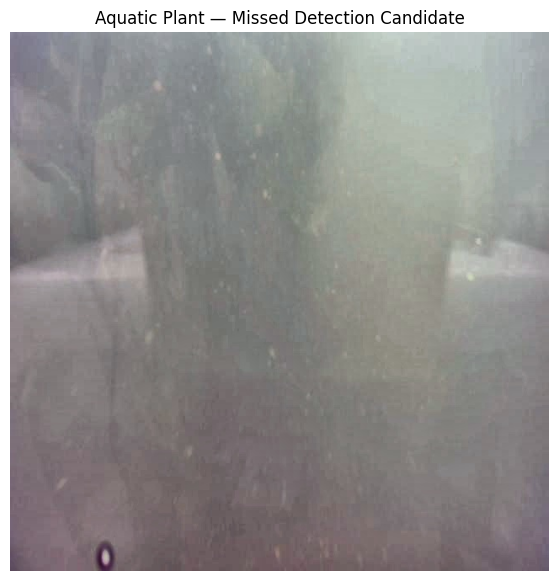

In [ ]:
failure_ap=ap_df[
    (ap_df["ground_truth_objects"]>0) &
    (ap_df["detections"]==0)
].iloc[0]["image"]
failure_ap_path=os.path.join(AP_IMAGES,failure_ap)
failure_ap_label=os.path.join(
    AP_LABELS,
    os.path.splitext(failure_ap)[0]+".txt"
)
print("Image:",failure_ap)
print("Label:",failure_ap_label)
with open(failure_ap_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in lines:
    print(line)
img=cv2.imread(failure_ap_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Aquatic Plant — Missed Detection Candidate")
plt.show()

### Aquatic Plant — Confirmed Error Case 1

- Error type: False Negative / Missed Detection
- Ground truth: Aquatic Plant
- Model prediction: No detection
- Observation: The image has low visibility and a hazy appearance,and the annotated plant is difficult to distinguish clearly.
- Interpretation: The model missed the annotated Aquatic Plant in this visually difficult scene.

Image: 2023-12-09_13_20_33_mp4-6_jpg.rf.45756f1c0d45d640819f1309e9c97699.jpg
Label: /content/Day25_Data/Aquatic_Plant/labels/2023-12-09_13_20_33_mp4-6_jpg.rf.45756f1c0d45d640819f1309e9c97699.txt

Ground-truth label:
0 0.56640625 0.60078125 0.55078125 0.7828125


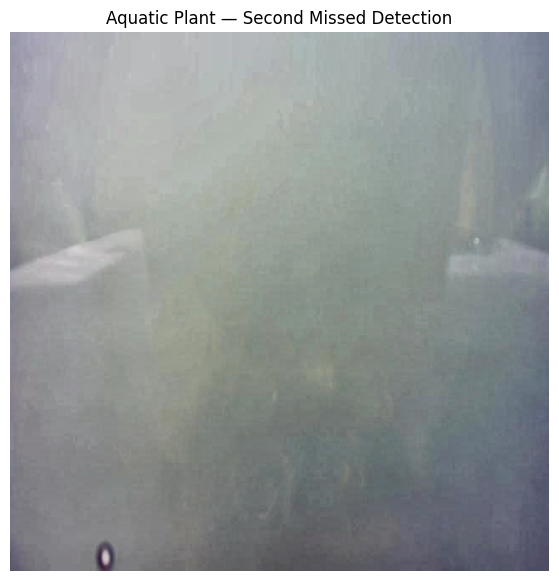

In [ ]:
failure_ap=ap_df[
    (ap_df["ground_truth_objects"]>0) &
    (ap_df["detections"]==0)
].iloc[1]["image"]
failure_ap_path=os.path.join(AP_IMAGES,failure_ap)
failure_ap_label=os.path.join(
    AP_LABELS,
    os.path.splitext(failure_ap)[0]+".txt"
)
print("Image:",failure_ap)
print("Label:",failure_ap_label)
with open(failure_ap_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in lines:
    print(line)
img=cv2.imread(failure_ap_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Aquatic Plant — Second Missed Detection")
plt.show()

### Aquatic Plant — Confirmed Error Case 2

- Error type: False Negative / Missed Detection
- Ground truth: Aquatic Plant
- Model prediction: No detection
- Observation: The image shows very low visibility and a hazy underwater appearance,and the annotated plant is difficult to distinguish from the background.
- Interpretation: The model missed the annotated Aquatic Plant in this visually difficult scene.

In [ ]:
ap_low_conf=ap_df[
    (ap_df["ground_truth_objects"]>0) &
    (ap_df["detections"]>0)
].sort_values("max_confidence")
print("Lowest-confidence Aquatic Plant detections:")
print(ap_low_conf.head(10))

Lowest-confidence Aquatic Plant detections:
                                                image  ground_truth_objects  \
47  2023-12-09_13_20_33_mp4-95_jpg.rf.6e8d076c8eca...                     1   
62  2023-12-09_13_20_33_mp4-465_jpg.rf.6928ea3f2a2...                     1   
65  2023-12-09_13_20_33_mp4-134_jpg.rf.02a3ca6c396...                     2   
57  2023-12-09_13_18_14_mp4-420_jpg.rf.46b9dc68e2e...                     1   
53  2023-12-09_13_20_33_mp4-210_jpg.rf.5ee64638e7c...                     1   
87  2023-12-09_13_20_33_mp4-149_jpg.rf.7ee0c7dbf89...                     1   
54  2023-12-09_13_18_14_mp4-424_jpg.rf.5085a352bf6...                     1   
49  2023-12-09_13_18_14_mp4-436_jpg.rf.3b1e3417e4f...                     1   
32  2023-12-09_13_18_14_mp4-449_jpg.rf.af34b5b315c...                     1   
12  2023-12-09_13_20_33_mp4-132_jpg.rf.99d960fc207...                     2   

    detections  max_confidence  
47           1        0.427402  
62           1      

Image: 2023-12-09_13_20_33_mp4-95_jpg.rf.6e8d076c8eca9e79e2b226565fa65bb9.jpg
Label: /content/Day25_Data/Aquatic_Plant/labels/2023-12-09_13_20_33_mp4-95_jpg.rf.6e8d076c8eca9e79e2b226565fa65bb9.txt

Ground-truth label:
0 0.49765625 0.49921875 0.9765625 0.9796875


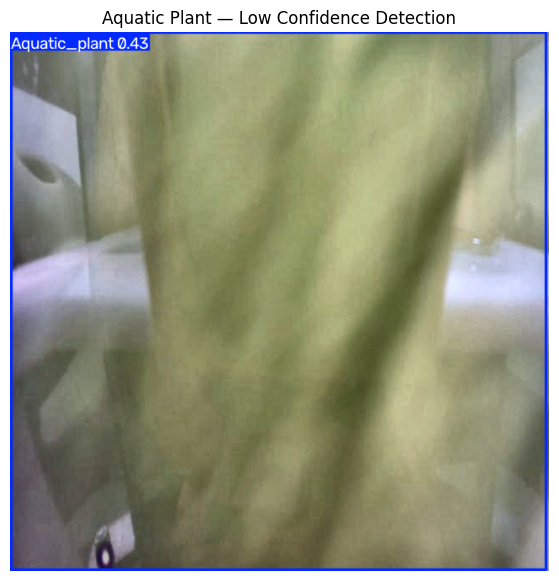


Predictions:
Class: 0 | Confidence: 0.427


In [ ]:
low_conf_image=ap_low_conf.iloc[0]["image"]

low_conf_path=os.path.join(AP_IMAGES,low_conf_image)

low_conf_label=os.path.join(
    AP_LABELS,
    os.path.splitext(low_conf_image)[0]+".txt"
)

print("Image:",low_conf_image)
print("Label:",low_conf_label)

with open(low_conf_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]

print("\nGround-truth label:")
for line in lines:
    print(line)

result=ap_model.predict(
    source=low_conf_path,
    conf=0.25,
    imgsz=640,
    device=0,
    verbose=False
)[0]

annotated=result.plot()
annotated_rgb=cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Aquatic Plant — Low Confidence Detection")
plt.show()

print("\nPredictions:")
for box in result.boxes:
    print(
        "Class:",int(box.cls.item()),
        "| Confidence:",round(float(box.conf.item()),3)
    )

### Aquatic Plant — Low Confidence Case

- Ground truth: Aquatic Plant
- Model prediction: Aquatic Plant
- Confidence: 0.427
- Observation: The model correctly detected the plant,but with relatively low confidence.
- Visual condition: The image has a hazy underwater appearance,and the plant occupies most of the image.
- Interpretation: The model was able to detect the plant,but showed lower confidence in this visually difficult scene.

## Aquatic Plant — Error Analysis Summary

- Evaluation images: 89
- Final model: H03 — WB+CLAHE + YOLOv8n
- Ground-truth images containing Aquatic Plant: 51

### Confirmed Errors

1. **Missed Detection**
   - Ground truth: Aquatic Plant
   - Prediction: No detection
   - Observation: The image had low visibility and a hazy underwater appearance.

2. **Missed Detection**
   - Ground truth: Aquatic Plant
   - Prediction: No detection
   - Observation: The scene was highly hazy and the plant was difficult to distinguish from the background.

3. **Low-Confidence Detection**
   - Ground truth: Aquatic Plant
   - Prediction: Aquatic Plant
   - Confidence: 0.427
   - Observation: The model detected the plant correctly but with relatively low confidence.

### Main Observations

- Missed detections occurred in visually difficult underwater scenes.
- Hazy and low-visibility conditions were observed in the missed cases.
- The model can correctly detect the plant but may show lower confidence in difficult scenes.

### Limitation

- The analysis used the available 89-image test set.
- The exact cause of each detection failure cannot be determined from individual examples alone.

### Conclusion

The Aquatic Plant model showed missed detections in difficult underwater scenes and lower confidence in some challenging images.

In [ ]:
WELL_OUTPUT="/content/Day25_Predictions/Well"
os.makedirs(WELL_OUTPUT,exist_ok=True)
well_results=well_model.predict(
    source=WELL_IMAGES,
    conf=0.25,
    imgsz=640,
    device=0,
    save=True,
    project="/content/Day25_Predictions",
    name="Well",
    exist_ok=True
)
print("Well prediction completed.")


image 1/184 /content/Day25_Data/Well/images/20240102-20240102153559-20240102153818-153600_mp4-0007_jpg.rf.80c4d58a4513785834755e382a19ac8b.jpg: 640x640 22 fishess, 7.2ms
image 2/184 /content/Day25_Data/Well/images/20240102-20240102153559-20240102153818-153600_mp4-0009_jpg.rf.6161baaa8836b91a9f3d3823af2716de.jpg: 640x640 22 fishess, 1 school-of-fish, 8.4ms
image 3/184 /content/Day25_Data/Well/images/20240102-20240102153559-20240102153818-153600_mp4-0029_jpg.rf.00e461a44e2537925908d9b50c12edd4.jpg: 640x640 19 fishess, 7.2ms
image 4/184 /content/Day25_Data/Well/images/20240102-20240102153559-20240102153818-153600_mp4-0043_jpg.rf.835d3fb6f884a14c9460858a3ab837c5.jpg: 640x640 27 fishess, 7.2ms
image 5/184 /content/Day25_Data/Well/images/20240102-20240102153559-20240102153818-153600_mp4-0051_jpg.rf.0381c467f32c6f971b119ee4d759c97a.jpg: 640x640 31 fishess, 1 school-of-fish, 7.2ms
image 6/184 /content/Day25_Data/Well/images/20240102-20240102153559-20240102153818-153600_mp4-0059_jpg.rf.087fa97

In [ ]:
files=os.listdir(WELL_OUTPUT)
print("Output exists:",os.path.exists(WELL_OUTPUT))
print("Number of output files:",len(files))
print("First 10 files:",files[:10])

Output exists: True
Number of output files: 184
First 10 files: ['20240102-20240102153559-20240102153818-153600_mp4-0051_jpg.rf.0381c467f32c6f971b119ee4d759c97a.jpg', '20240102-20240102153559-20240102153818-153600_mp4-0313_jpg.rf.e0e8640b0ad87c73f785d613dea96646.jpg', '20240102-20240102153559-20240102153818-153600_mp4-0206_jpg.rf.ee9d338a6ece89e00fad19dcaf41d78d.jpg', '20240102-20240102153559-20240102153818-153600_mp4-0474_jpg.rf.1cc71da135d50349a95633d8975012d1.jpg', '20240102-20240102153559-20240102153818-153600_mp4-0665_jpg.rf.ebd97877b610870ee35569138eb7aa77.jpg', '20240102-20240102153559-20240102153818-153600_mp4-1418_jpg.rf.f5fc349cf453833a4cb9294c93cd5752.jpg', '20240102-20240102153559-20240102153818-153600_mp4-0420_jpg.rf.4feb9e48635b5f0d7775dbe3322208a5.jpg', '20240102-20240102153559-20240102153818-153600_mp4-0534_jpg.rf.a11ce9a38a4d8d8388dbfeeee0db5870.jpg', '20240102-20240102153559-20240102153818-153600_mp4-1064_jpg.rf.7333dd8bc038904fee615a47cff7713f.jpg', '20240102-2024010

In [ ]:
WELL_LABELS="/content/Day25_Data/Well/labels"

well_image_files=[
    os.path.join(WELL_IMAGES,f)
    for f in os.listdir(WELL_IMAGES)
    if f.lower().endswith((".jpg",".jpeg",".png"))
]

well_analysis=[]

for image_path in well_image_files:
    image_name=os.path.basename(image_path)

    label_path=os.path.join(
        WELL_LABELS,
        os.path.splitext(image_name)[0]+".txt"
    )

    gt_count=0
    if os.path.exists(label_path):
        with open(label_path,"r") as f:
            gt_count=len([line for line in f if line.strip()])

    result=well_model.predict(
        source=image_path,
        conf=0.25,
        imgsz=640,
        device=0,
        verbose=False
    )[0]

    detections=0
    max_confidence=0

    if result.boxes is not None and len(result.boxes)>0:
        detections=len(result.boxes)
        max_confidence=float(result.boxes.conf.max().item())

    well_analysis.append({
        "image":image_name,
        "ground_truth_objects":gt_count,
        "detections":detections,
        "max_confidence":max_confidence
    })

well_df=pd.DataFrame(well_analysis)

print("Total images:",len(well_df))
print("Images with ground-truth objects:",
      (well_df["ground_truth_objects"]>0).sum())

print("\nPossible missed detections:")
print(
    well_df[
        (well_df["ground_truth_objects"]>0) &
        (well_df["detections"]==0)
    ].sort_values("ground_truth_objects",ascending=False)
)

Total images: 184
Images with ground-truth objects: 163

Possible missed detections:
                                                 image  ground_truth_objects  \
9    20240102-20240102153559-20240102153818-153600_...                     1   
31   20240102-20240102153559-20240102153818-153600_...                     1   
44   20240102-20240102153559-20240102153818-153600_...                     1   
101  20240102-20240102153559-20240102153818-153600_...                     1   

     detections  max_confidence  
9             0             0.0  
31            0             0.0  
44            0             0.0  
101           0             0.0  


Image: 20240102-20240102153559-20240102153818-153600_mp4-0185_jpg.rf.b46c18935e17fe79136cd681f92b31ca.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-0185_jpg.rf.b46c18935e17fe79136cd681f92b31ca.txt

Ground-truth label:
1 0.10625 0.96875 0.06171875 0.05703125


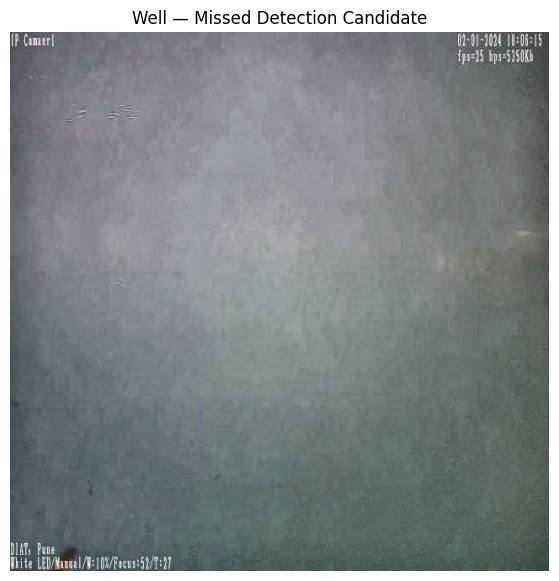

In [ ]:
failure_well=well_df[
    (well_df["ground_truth_objects"]>0) &
    (well_df["detections"]==0)
].iloc[0]["image"]
failure_well_path=os.path.join(WELL_IMAGES,failure_well)
failure_well_label=os.path.join(
    WELL_LABELS,
    os.path.splitext(failure_well)[0]+".txt"
)
print("Image:",failure_well)
print("Label:",failure_well_label)
with open(failure_well_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in lines:
    print(line)
img=cv2.imread(failure_well_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Well — Missed Detection Candidate")
plt.show()

### Well — Confirmed Error Case 1

- Error type: False Negative / Missed Detection
- Ground truth: fishes
- Model prediction: No detection
- Observation: The annotated object is very small and located close to the bottom-left image boundary.
- Visual condition: The scene has low visibility and the object is difficult to distinguish from the background.
- Interpretation: The model missed a small fishes object in a visually difficult scene.

Image: 20240102-20240102153559-20240102153818-153600_mp4-0114_jpg.rf.8d205833404a8802e8cfcec52f7ebf28.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-0114_jpg.rf.8d205833404a8802e8cfcec52f7ebf28.txt

Ground-truth label:
3 0.159375 0.5 0.31875 1


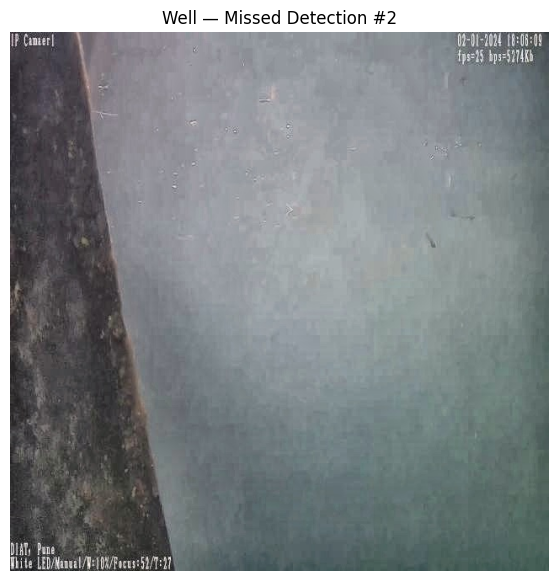

In [ ]:
failure_well=well_df[
    (well_df["ground_truth_objects"]>0) &
    (well_df["detections"]==0)
].iloc[1]["image"]
failure_well_path=os.path.join(WELL_IMAGES,failure_well)
failure_well_label=os.path.join(
    WELL_LABELS,
    os.path.splitext(failure_well)[0]+".txt"
)
print("Image:",failure_well)
print("Label:",failure_well_label)
with open(failure_well_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in lines:
    print(line)
img=cv2.imread(failure_well_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Well — Missed Detection #2")
plt.show()

### Well — Confirmed Error Case 2

- Error type: False Negative / Missed Detection
- Ground truth: stone
- Model prediction: No detection
- Observation: The stone occupies a large region along the left side of the image and extends across the image height.
- Visual condition: The scene has low visibility and underwater haze.
- Interpretation: The model missed the annotated stone in this difficult scene.

Image: 20240102-20240102153559-20240102153818-153600_mp4-0117_jpg.rf.ccbb2251799643b32ef949f5f7783ae2.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-0117_jpg.rf.ccbb2251799643b32ef949f5f7783ae2.txt

Ground-truth label:
3 0.10546875 0.49765625 0.2109375 0.9953125


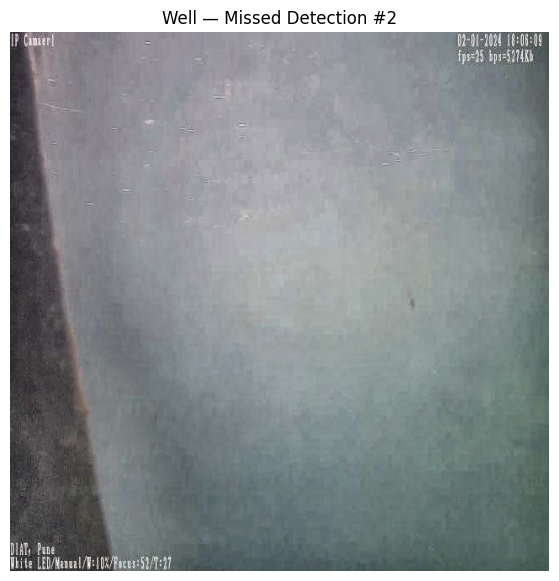

In [ ]:
failure_well=well_df[
    (well_df["ground_truth_objects"]>0) &
    (well_df["detections"]==0)
].iloc[2]["image"]
failure_well_path=os.path.join(WELL_IMAGES,failure_well)
failure_well_label=os.path.join(
    WELL_LABELS,
    os.path.splitext(failure_well)[0]+".txt"
)
print("Image:",failure_well)
print("Label:",failure_well_label)
with open(failure_well_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in lines:
    print(line)
img=cv2.imread(failure_well_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Well — Missed Detection #2")
plt.show()

Image: 20240102-20240102153559-20240102153818-153600_mp4-1196_jpg.rf.9acb0d723669dec95f7afe809da41abe.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-1196_jpg.rf.9acb0d723669dec95f7afe809da41abe.txt

Ground-truth label:
1 0.0109375 0.196875 0.021875 0.046875


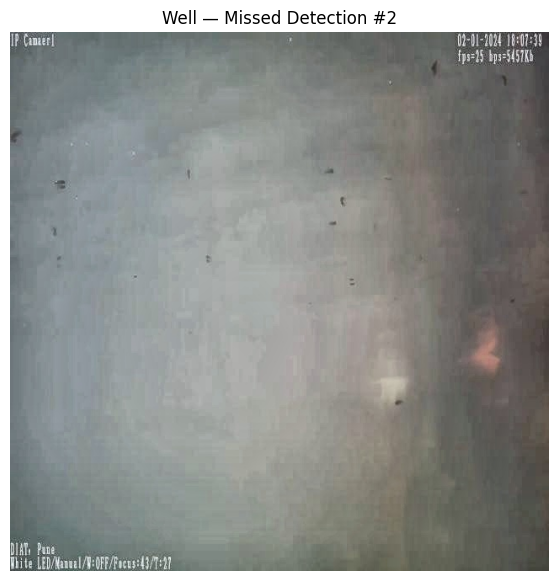

In [ ]:
failure_well=well_df[
    (well_df["ground_truth_objects"]>0) &
    (well_df["detections"]==0)
].iloc[3]["image"]
failure_well_path=os.path.join(WELL_IMAGES,failure_well)
failure_well_label=os.path.join(
    WELL_LABELS,
    os.path.splitext(failure_well)[0]+".txt"
)
print("Image:",failure_well)
print("Label:",failure_well_label)
with open(failure_well_label,"r") as f:
    lines=[line.strip() for line in f if line.strip()]
print("\nGround-truth label:")
for line in lines:
    print(line)
img=cv2.imread(failure_well_path)
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Well — Missed Detection #2")
plt.show()

In [ ]:
well_low_conf=well_df[
    (well_df["detections"]>0)
].sort_values("max_confidence",ascending=True).head(10)

print("Lowest-confidence Well detections:")
print(well_low_conf)

Lowest-confidence Well detections:
                                                 image  ground_truth_objects  \
104  20240102-20240102153559-20240102153818-153600_...                     1   
15   20240102-20240102153559-20240102153818-153600_...                     0   
112  20240102-20240102153559-20240102153818-153600_...                     1   
169  20240102-20240102153559-20240102153818-153600_...                     0   
151  20240102-20240102153559-20240102153818-153600_...                     0   
30   20240102-20240102153559-20240102153818-153600_...                     0   
61   20240102-20240102153559-20240102153818-153600_...                     0   
98   20240102-20240102153559-20240102153818-153600_...                     2   
56   20240102-20240102153559-20240102153818-153600_...                     1   
107  20240102-20240102153559-20240102153818-153600_...                     0   

     detections  max_confidence  
104           1        0.286660  
15            2 


LOW-CONFIDENCE CASE 1
Image: 20240102-20240102153559-20240102153818-153600_mp4-0111_jpg.rf.13eae243fea57a4c3d402718fe342a84.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-0111_jpg.rf.13eae243fea57a4c3d402718fe342a84.txt

Ground-truth labels:
1 0.96328125 0.0359375 0.0734375 0.071875

Predictions:
Class: 1 | Confidence: 0.287


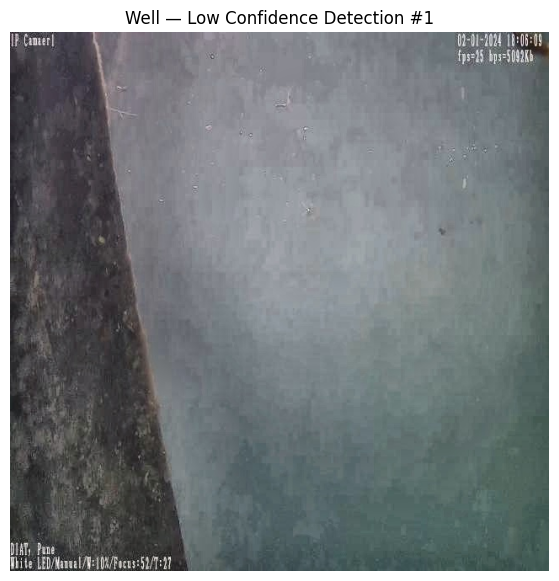


LOW-CONFIDENCE CASE 2
Image: 20240102-20240102153559-20240102153818-153600_mp4-1542_jpg.rf.7ada681b0141414e7fbc99018f79135f.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-1542_jpg.rf.7ada681b0141414e7fbc99018f79135f.txt

Ground-truth labels:

Predictions:
Class: 1 | Confidence: 0.338
Class: 1 | Confidence: 0.31


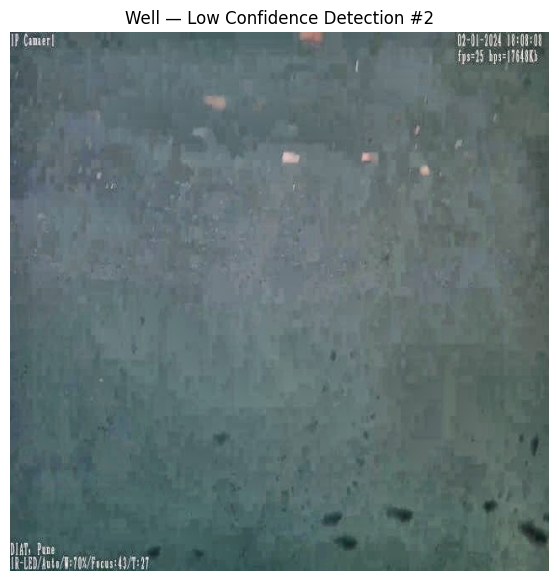


LOW-CONFIDENCE CASE 3
Image: 20240102-20240102153559-20240102153818-153600_mp4-0158_jpg.rf.20f1fe9a6793f51fb5a6d93371df582d.jpg
Label: /content/Day25_Data/Well/labels/20240102-20240102153559-20240102153818-153600_mp4-0158_jpg.rf.20f1fe9a6793f51fb5a6d93371df582d.txt

Ground-truth labels:
1 0.06796875 0.96328125 0.13515625 0.0734375

Predictions:
Class: 1 | Confidence: 0.357


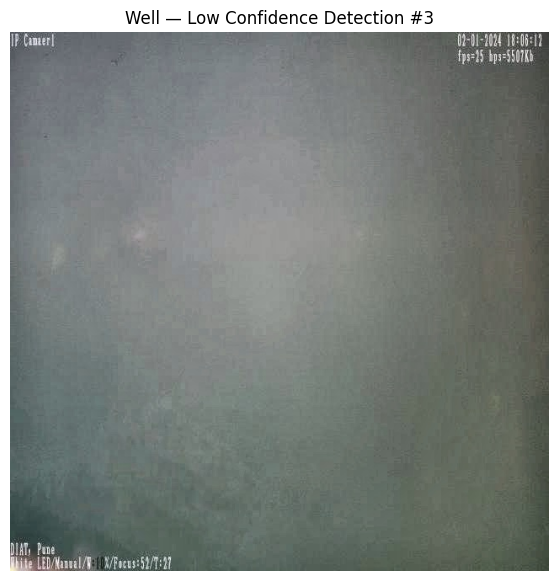

In [ ]:
for i in range(3):
    low_well=well_low_conf.iloc[i]["image"]
    low_well_path=os.path.join(WELL_IMAGES,low_well)

    low_well_label=os.path.join(
        WELL_LABELS,
        os.path.splitext(low_well)[0]+".txt"
    )

    print("\n"+"="*60)
    print("LOW-CONFIDENCE CASE",i+1)
    print("Image:",low_well)
    print("Label:",low_well_label)

    with open(low_well_label,"r") as f:
        lines=[line.strip() for line in f if line.strip()]

    print("\nGround-truth labels:")
    for line in lines:
        print(line)

    result=well_model.predict(
        source=low_well_path,
        conf=0.25,
        imgsz=640,
        device=0,
        verbose=False
    )[0]

    print("\nPredictions:")
    if result.boxes is not None and len(result.boxes)>0:
        for cls,conf in zip(result.boxes.cls,result.boxes.conf):
            print(
                "Class:",int(cls.item()),
                "| Confidence:",round(float(conf.item()),3)
            )
    else:
        print("No detections")

    img=cv2.imread(low_well_path)
    img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,7))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Well — Low Confidence Detection #{i+1}")
    plt.show()

## Well — Error Analysis Summary

- 4 images with ground-truth objects were completely missed by the model.
- Missed objects included fishes and stone classes.
- Several missed objects were very small or located near image boundaries.
- The stone class was difficult to detect in low-visibility scenes.
- Low-confidence detections were also observed for small fishes near image edges.
- Some low-confidence predictions occurred in images without ground-truth objects,indicating possible false positives.
- Overall,the main failure conditions were small objects,edge locations,low visibility and underwater haze.

# Day 25 — Detailed Error / Failure Analysis

## Objective

The objective was to inspect model predictions,identify missed detections and low-confidence predictions,and document recurring failure conditions across all three datasets.

## DIAT Aquarium

- 714 validation images contained ground-truth objects.
- A missed Camera object was observed in a low-visibility scene.
- Fish/Fishes predictions showed class-confusion and low-confidence detections.
- Some difficult images contained haze,poor visibility and visually similar objects.
- The Fishes class showed a notable reduction in detection performance after WB+CLAHE.
- Likely difficult conditions include haze,low contrast,small objects and Fish/Fishes similarity.

## Aquatic Plant

- 51 of 89 test images contained ground-truth aquatic plant objects.
- 2 images containing ground-truth plants were completely missed.
- Missed examples showed very poor visibility and strong underwater haze.
- Low-confidence detections were observed when the plant occupied a large area but had weak visual boundaries.
- Likely difficult conditions include haze,low contrast,blur and unclear plant boundaries.

## Well

- 4 images containing ground-truth objects were completely missed.
- Missed objects included fishes and stone.
- Several missed objects were very small or close to image boundaries.
- The stone class was difficult to detect in low-visibility scenes.
- Low-confidence fishes detections were observed near image boundaries.
- Some low-confidence predictions occurred in images without ground-truth objects,indicating possible false positives.
- Likely difficult conditions include small objects,edge locations,low visibility and underwater haze.

## Recurring Failure Conditions

Across the three datasets,the main recurring difficult conditions were:

- Low visibility and underwater haze
- Low contrast
- Small objects
- Objects near image boundaries
- Visually similar classes
- Weak or unclear object boundaries
- Possible false positives in difficult background regions

## Limitations

- Error analysis used representative prediction cases rather than manually inspecting every prediction.
- DIAT does not have a separate local test set.
- The Well dataset has strong class imbalance.
- The stone class remained difficult to detect.
- WB+CLAHE was evaluated as a combined enhancement method.
- Water-Net and FUnIE-GAN were reviewed but not implemented.
- Tracking was not evaluated because video data was unavailable.
- The exact cause of individual detection failures cannot always be determined from visual inspection alone.

## Conclusion

The error analysis shows that detection performance is affected by underwater visibility,object size,object location and class similarity.

The failure cases support the main research finding that the effect of image enhancement and YOLO detection is dataset-dependent.

The identified failure conditions can guide future improvements such as stronger data augmentation,better class balancing,more diverse training data and improved underwater enhancement methods.

In [ ]:
import os    #just checking all saved or not

DAY25="/content/Day25_Data"

print("Day25_Data exists:",os.path.exists(DAY25))

for root,dirs,files in os.walk(DAY25):
    level=root.replace(DAY25,"").count(os.sep)
    indent="  "*level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:10]:
        print(f"{indent}  {file}")
    if len(files)>10:
        print(f"{indent}  ... {len(files)} files total")

Day25_Data exists: True
Day25_Data/
  DIAT/
    labels.cache
    labels/
      av0_0_20240222_103703_000392_jpg.rf.492139677a6da9b53be422971d4d6211.txt
      av0_0_20240222_102152_004078_jpg.rf.031de75f340404ffb0dc9d8492c460bd.txt
      av0_0_20240222_102152_000486_jpg.rf.7abdb59a90a12a8a3b785c45b3329b3b.txt
      av0_0_20231228_102111_mp4-638_jpg.rf.51a2fad5948591ddd0911b77935769b1.txt
      av0_0_20240222_103703_001988_jpg.rf.682d21827204dfeae9ab8ede8f6beb8e.txt
      av0_0_20240222_102152_004062_jpg.rf.5c7c9a9f95c402fb7ff327797c0a3ca6.txt
      av0_0_20231228_102111_mp4-242_jpg.rf.20328612187ceb8f5927c4c997db7ef8.txt
      av0_0_20231228_094444_mp4-121_jpg.rf.f7a2532e271d10c61d4a7cca144f5707.txt
      av0_0_20231228_094444_mp4-667_jpg.rf.5822a40ff831eba270d11ae6f17696f0.txt
      av0_0_20231228_102111_mp4-60_jpg.rf.b58182a2006e7efcf703c56d61fc96dd.txt
      ... 773 files total
    images/
      av0_0_20240222_103703_005129_jpg.rf.3e0e540afe2bc9cff79282dc670099e4.jpg
      av0_0_2024

## Day 25 — Consolidated Limitations & Likely Failure Conditions

### Limitations
- DIAT has no separate local test set; this analysis uses the available validation set.
- Aquatic Plant's analysis is based on the 89-image test set only.
- The exact cause of any individual detection failure cannot be confirmed from visual inspection alone — observations describe likely contributing conditions,not verified root causes.
- Error inspection covered a sample of worst/lowest-confidence cases per dataset,not an exhaustive review of every prediction.
- Well's class imbalance (very few 'stone' and 'Inlet-pipe' instances) limits how much can be concluded about those classes specifically.

### Likely Failure Conditions (across all three datasets)
- Haze and low underwater visibility — the most recurring factor in missed detections across DIAT,Aquatic Plant,and Well.
- Small objects and objects near image boundaries — particularly affected Well (fishes,stone).
- Visually similar/confusable classes — DIAT's Fish vs. Fishes showed class-confusion and overlapping/duplicate box predictions.
- Severe class imbalance — Well's rare classes (stone,Inlet-pipe) had few or no confident correct detections.
- Low-contrast or low-confidence borderline cases — present in all three datasets,suggesting lower model confidence in difficult scenes.

## Conclusion
Across DIATAquarium,Aquatic Plant,and Well,the dominant failure pattern was underwater visibility conditions such as haze and low contrast. Class-level issues were dataset-specific: DIAT showed Fish/Fishes confusion,while Well's failures were associated with class imbalance and small or edge-located objects.

These findings support the project's overall observation that enhancement and detection performance are dataset- and class-dependent rather than uniform across all three datasets.